# Prompt Chaining

## Definition of Prompt Chaining

Prompt chaining is a technique in natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the task into smaller, manageable steps, with each step building on the previous one. This approach can improve accuracy, coherence, and control when working with large language models.

LangGraph, is a framework designed to facilitate structured interactions with language models, making it an excellent tool for implementing prompt chaining. It allows you to define a graph of nodes (representing individual prompts or tasks) and edges (representing the flow of information between them). This structure enables dynamic, multi-step conversations or workflows, where the output of one node can feed into the input of the next.

## How Prompt Chaining Works with LangGraph

1. Define the Task: Start by breaking down the problem into smaller sub-tasks. For example, if you want to generate a detailed report, you might split it into steps like "gather data," "analyze data," and "write summary."

2. Create Nodes: Each sub-task becomes a node in the LangGraph structure. A node could be a prompt that instructs the model to perform a specific action, such as "List key facts about X" or "Summarize the following text."

3. Establish Edges: Edges define the sequence and dependencies between nodes. For instance, the output of the "gather data" node flows into the "analyze data" node, ensuring the model has the necessary context to proceed.

4. Execute the Graph: LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. Iterate if Needed: LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.

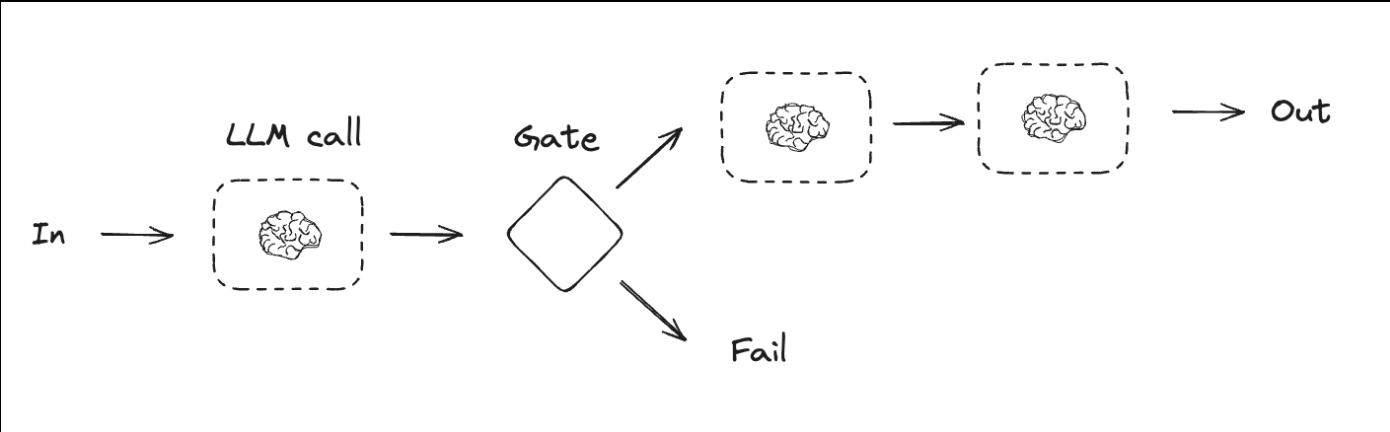

## Problem Statement

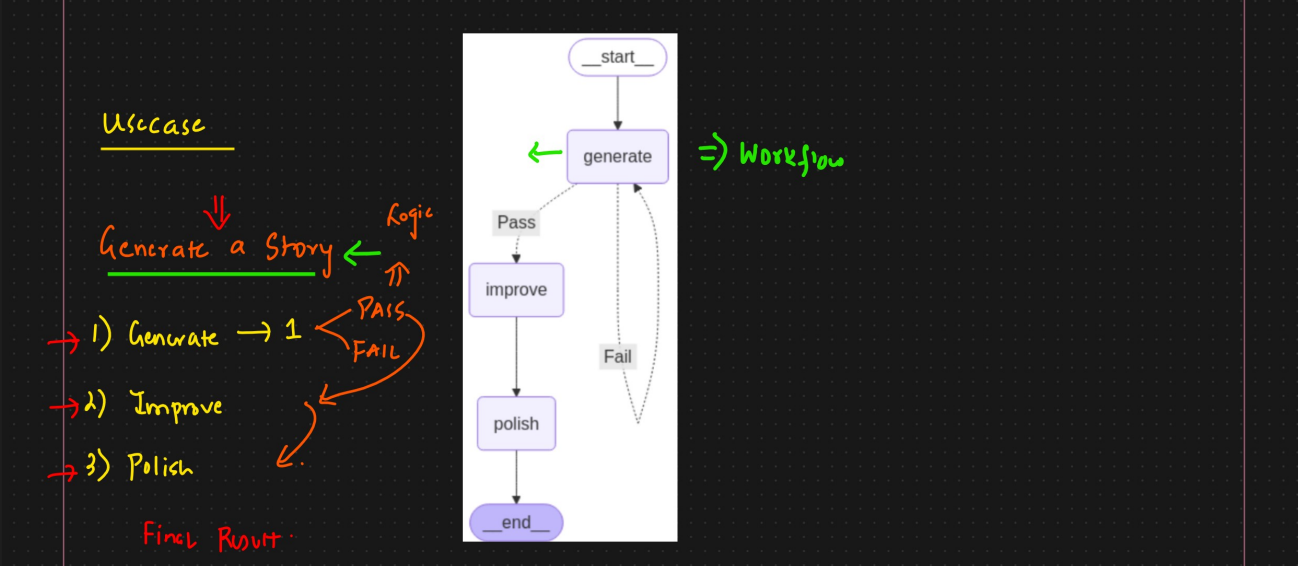

## Solution

### Setting Up the Chat Model

In [ ]:
### Importing Required Libraries
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="openai/gpt-oss-120b")

result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello". We should respond politely. There\'s no special instruction. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 72, 'total_tokens': 111, 'completion_time': 0.081982869, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.014325638, 'prompt_tokens_details': None, 'queue_time': 0.327642747, 'total_time': 0.096308507}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_854fa9be4c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f826-a7b2-7392-9cc5-2687314274a9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 39, 'total_tokens': 111, 'output_token_details': {'reasoning': 21}})

### Defining the State Schema and Graph Nodes

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

### Creating the Graph State
class State(TypedDict):
    topic:str
    story:str
    improved_story:str
    final_story:str

### Defining the Graph Nodes

### Generating the Story
def generate_story(state:State):
    msg=llm.invoke(f"Write a one sentence story premise about {state["topic"]}")
    return {"story":msg.content}

### Checking for Conflicts
def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    return "Pass"

### Improving the Story
def improved_story(state:State):
    msg=llm.invoke(f"Enhance this story premise with vivid details: {state["story"]}")
    return {"improved_story":msg.content}

### Polishing the Story
def polish_story(state:State):
    msg=llm.invoke(f"Add an unexpected twist to this story premise. {state["improved_story"]}")
    return {"final_story":msg.content}

### Building the Prompt Chain

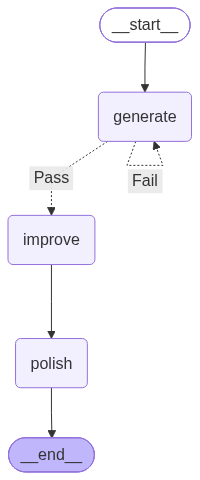

In [ ]:
### Creating the StateGraph
graph=StateGraph(State)

### Adding the Graph Nodes
graph.add_node("generate", generate_story)
graph.add_node("improve", improved_story)
graph.add_node("polish", polish_story)

### Adding the Graph Edges
graph.add_edge(START, "generate")
graph.add_conditional_edges("generate", check_conflict, {"Pass":"improve", "Fail":"generate"})
graph.add_edge("improve", "polish")
graph.add_edge("polish", END)

### Compiling the Graph
compiled_graph=graph.compile()

### Visualizing the Prompt Chain
graph_image=compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

### Running the Prompt Chain

#### Providing the Initial State

In [ ]:
state={"topic":"Rohit Sharma"}
result=compiled_graph.invoke(state)
result

{'topic': 'Rohit Sharma in short',
 'story': 'Rohit Sharma, the cricket legend, discovers a mysterious, ancient bat that lets him relive his greatest innings—only to find each replay reshapes the present in unexpected ways.',
 'improved_story': '**Title:\u202fThe Echoes of the Willow**\n\n**Logline**  \nWhen Indian cricket icon Rohit Sharma uncovers an ancient, rune‑etched bat hidden in a forgotten temple, every swing lets him replay his most legendary innings—yet each perfect knock ripples through time, reshaping the present in ways no fan could ever imagine.\n\n---\n\n### 1. The Discovery  \n\n*The Temple of the Whispering Willow*—a crumbling sandstone sanctuary perched on the mist‑shrouded cliffs of Mahabaleshwar, its walls covered in faded murals of warriors brandishing curved sticks. Inside a vaulted chamber, dust motes dance in shafts of amber light that pierce the gloom. At the heart of the room rests a solitary wooden relic on a stone pedestal, swathed in a tattered saffron clo

#### Displaying the Improved Story

In [15]:
print("Improved Story:-")
print(result["improved_story"])

Improved Story:-
**Title: The Echoes of the Willow**

**Logline**  
When Indian cricket icon Rohit Sharma uncovers an ancient, rune‑etched bat hidden in a forgotten temple, every swing lets him replay his most legendary innings—yet each perfect knock ripples through time, reshaping the present in ways no fan could ever imagine.

---

### 1. The Discovery  

*The Temple of the Whispering Willow*—a crumbling sandstone sanctuary perched on the mist‑shrouded cliffs of Mahabaleshwar, its walls covered in faded murals of warriors brandishing curved sticks. Inside a vaulted chamber, dust motes dance in shafts of amber light that pierce the gloom. At the heart of the room rests a solitary wooden relic on a stone pedestal, swathed in a tattered saffron cloth.

The bat is unlike any Rohit has ever seen. Its shaft is a deep, almost black ebony, veined with iridescent gold that seems to pulse like a heartbeat. The blade is broader than a modern blade, its surface etched with archaic Devanagari scr

#### Displaying the Polished Story

In [16]:
print("Polished Story:-")
print(result["final_story"])

Polished Story:-
## The Unexpected Twist – *The Willow Is a Prison, Not a Gift*

### 1. What the Bat Really Is  

The ancient “Chitraksh” is **not a relic that simply records past strikes**. It is a **sentient, time‑bound entity**—the dormant heart of a forgotten cricket‑god called **Vṛkṣa‑Mṛg**, the “Willow‑Beast”.  

Centuries ago, Vṛkṣa‑Mṛg was a celestial being who **wove the rhythm of the universe into the very act of hitting a ball**. When mortals began to worship the sport, the god offered his power to humanity, binding his essence into a wooden vessel so that his music could be heard on Earth. The rune‑etched bat was that vessel, a **prison** designed to keep the god’s infinite potential from tearing reality apart.

Every time Rohit swings the bat, he does more than replay a memory: **he releases a fragment of Vṛkṣa‑Mṛg’s consciousness**. The fragment “borrows” the exact moment it needs—hence the perfect innings—while simultaneously **re‑stitching that fragment into the present

## Benefits of Prompt Chaining with LangGraph

- Improved Context Management: By breaking tasks into smaller prompts, the model can focus on one aspect at a time, reducing the risk of losing context in long inputs.

- Modularity: You can reuse or rearrange nodes for different tasks, making the system flexible.

- Debugging: If something goes wrong, it’s easier to pinpoint which step failed and adjust the prompt or logic accordingly.

- Complex Reasoning: Chaining prompts allows the model to "think" step-by-step, mimicking human problem-solving more effectively.